Task 1


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
WORK_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()

FEATURE_NAMES = ['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport',
                 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac',
                 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts',
                 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory']

def _find(patterns, exclude_kw=()):
    seen, out = set(), []
    for p in patterns:
        for f in glob.glob(p, recursive=True):
            if f not in seen and not any(k in os.path.basename(f).lower() for k in exclude_kw):
                seen.add(f); out.append(f)
    return sorted(out)

FULL_DATASET_SAMPLE_FRAC = 0.07

def load_dataset(max_rows_full=1_000_000):
    """Always loads BOTH: 100% of the 5% source + a stratified-by-category slice
    of the full/OneDrive source, printing counts for each. Raises only if neither is found."""
    frames = []

    sample_files = _find(
        ['/kaggle/input/**/5/**/*.csv', '/kaggle/input/**/*5%*/**/*.csv',
         '/kaggle/input/**/*Full5pc*.csv', os.path.join(os.getcwd(), '**', '*Full5pc*.csv')],
        exclude_kw=('10-best', '10_best', 'final_10'))
    print(f"5% source: {len(sample_files)} file(s) found")
    if sample_files:
        sdf = pd.concat([pd.read_csv(f, low_memory=False) for f in sample_files], ignore_index=True)
        print(f"5% source: {len(sdf):,} rows loaded")
        frames.append(sdf)

    full_files = _find(
        ['/kaggle/input/**/OneDrive_2026-07-25/**/*.csv', '/kaggle/input/**/*Entire Dataset*/**/*.csv',
         '/kaggle/input/**/*Botnet_Dataset*.csv', os.path.join(os.getcwd(), '**', '*Botnet_Dataset_*.csv')],
        exclude_kw=('feature_names',))
    print(f"Full source: {len(full_files)} file(s) found")
    if full_files:
        per_file = max(1, max_rows_full // len(full_files))
        fdf = pd.concat([pd.read_csv(f, header=None, names=FEATURE_NAMES, nrows=per_file, low_memory=False)
                          for f in full_files], ignore_index=True)
        strat_col = 'category' if 'category' in fdf.columns else fdf.columns[-1]
        fdf = fdf.groupby(strat_col, group_keys=False).apply(
            lambda g: g.sample(frac=FULL_DATASET_SAMPLE_FRAC, random_state=42) if len(g) else g)
        print(f"Full source: {len(fdf):,} rows loaded (stratified)")
        frames.append(fdf)

    if not frames:
        raise FileNotFoundError(
            "No dataset found. Attach either '5%.zip' or 'OneDrive_2026-07-25.zip' "
            "(UNSW-NB18 IoT Botnet dataset) to this notebook via 'Add Input' on Kaggle."
        )
    combined = pd.concat(frames, ignore_index=True)
    print(f"Combined shape: {combined.shape}")
    return combined

print("Setup done")


Setup done


## Data Loading & Cleaning

In [ ]:
df = load_dataset()
print("Raw shape:", df.shape)

DROP_COLS = ['pkSeqID', 'stime', 'ltime', 'saddr', 'daddr', 'sport', 'dport', 'smac', 'dmac', 'soui', 'doui', 'sco', 'dco']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

miss = df.isnull().sum()
print("Missing values:\n", miss[miss > 0] if miss.sum() else "none")
for c in df.select_dtypes(include=[np.number]).columns:
    df[c] = df[c].fillna(df[c].median())
for c in df.select_dtypes(exclude=[np.number]).columns:
    df[c] = df[c].fillna(df[c].mode()[0])
print("Clean shape:", df.shape)


5% source: 4 file(s) found
5% source: 3,668,522 rows loaded
Full source: 74 file(s) found
Full source: 69,998 rows loaded (stratified)
Combined shape: (3738520, 52)
Raw shape: (3738520, 52)
Missing values:
 flgs_number                         69982
proto_number                        69982
state_number                        69982
TnBPSrcIP                           69982
TnBPDstIP                           69982
TnP_PSrcIP                          69982
TnP_PDstIP                          69982
TnP_PerProto                        69982
TnP_Per_Dport                       69982
AR_P_Proto_P_SrcIP                  69982
AR_P_Proto_P_DstIP                  69982
N_IN_Conn_P_DstIP                   69982
N_IN_Conn_P_SrcIP                   69982
AR_P_Proto_P_Sport                  69982
AR_P_Proto_P_Dport                  69982
Pkts_P_State_P_Protocol_P_DestIP    69982
Pkts_P_State_P_Protocol_P_SrcIP     69982
dtype: int64
Clean shape: (3738504, 39)


## Dataset Overview & Target Distribution

In [ ]:
print("Attack vs Normal:\n", df['attack'].value_counts())
print("\nCategory counts:\n", df['category'].value_counts())
print("\nSubcategory counts:\n", df['subcategory'].value_counts())
display(df.describe().T)


Attack vs Normal:
 attack
1    3738018
0        486
Name: count, dtype: int64

Category counts:
 category
DDoS              1963507
DoS               1681463
Reconnaissance      92969
Normal                486
Theft                  79
Name: count, dtype: int64

Subcategory counts:
 subcategory
UDP                  2018163
TCP                  1624333
Service_Scan           75055
OS_Fingerprint         17914
HTTP                    2474
Normal                   486
Keylogging                73
Data_Exfiltration          6
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
flgs_number,3738504.0,1.481029,0.859679,1.0,1.000000,1.000000,2.000000,9.000000e+00
proto_number,3738504.0,2.112808,0.997245,1.0,1.000000,3.000000,3.000000,5.000000e+00
pkts,3738504.0,7.699019,114.630622,1.0,5.000000,7.000000,9.000000,7.005700e+04
bytes,3738504.0,863.909965,111227.046113,60.0,420.000000,600.000000,770.000000,7.183334e+07
state_number,3738504.0,3.150593,1.181647,1.0,3.000000,4.000000,4.000000,1.100000e+01
seq,3738504.0,121481.538680,76060.315109,1.0,54871.000000,117818.000000,185202.000000,4.332000e+05
dur,3738504.0,20.391327,21.463545,0.0,12.545524,15.591657,27.173218,2.771485e+03
mean,3738504.0,2.222864,1.520942,0.0,0.177186,2.687842,3.562694,4.999673e+00
stddev,3738504.0,0.885442,0.805307,0.0,0.028671,0.772270,1.745305,2.498795e+00
sum,3738504.0,7.684786,7.637078,0.0,0.331033,8.257759,11.701786,1.913194e+03


## Visualizations

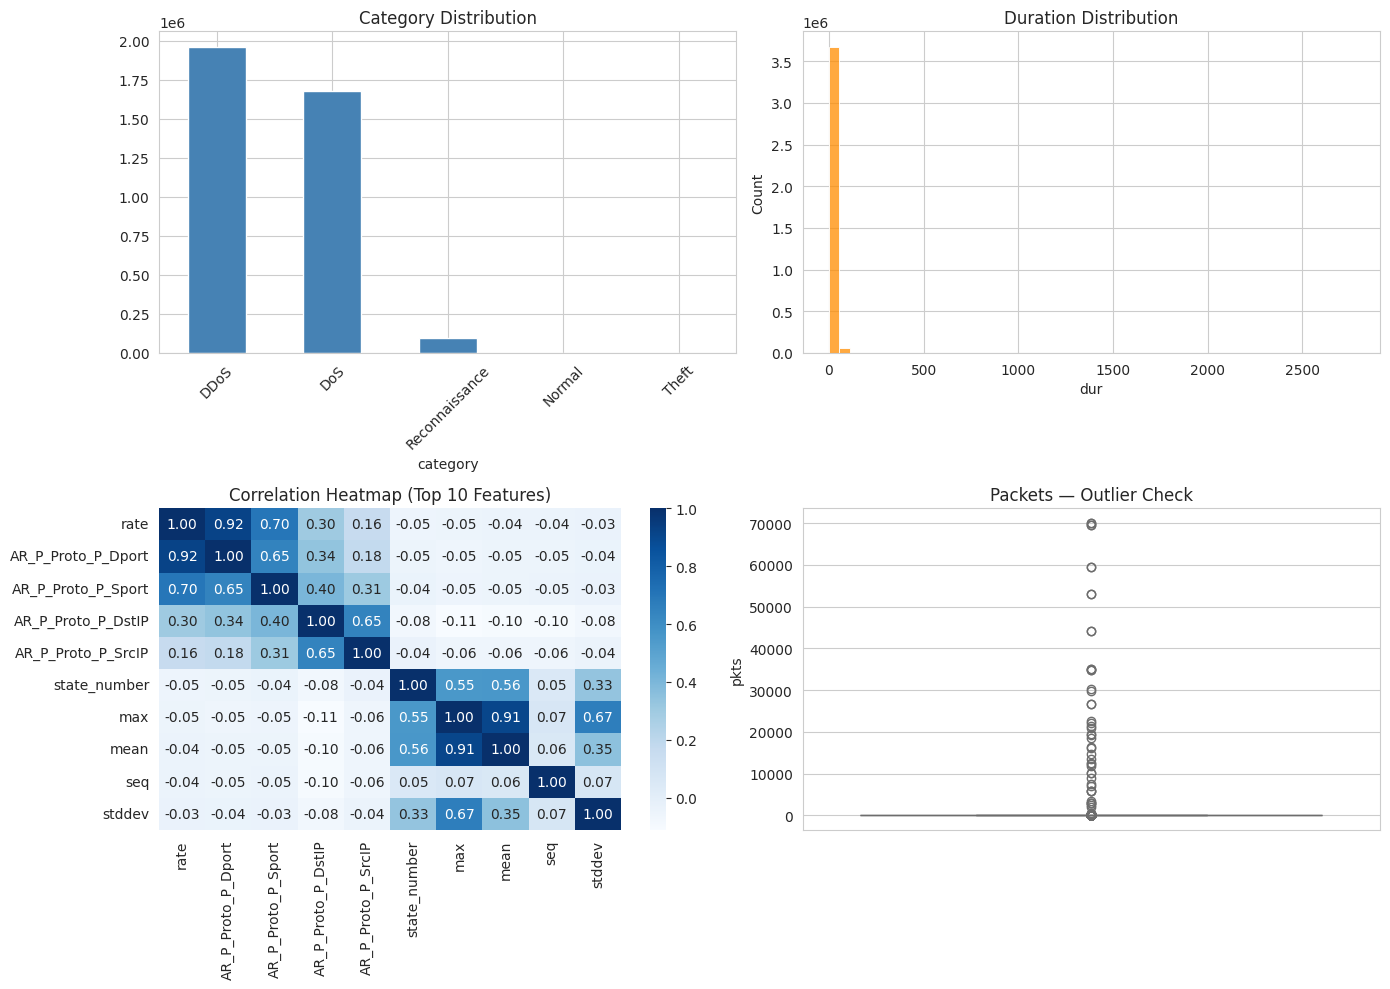

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['category'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Category Distribution'); axes[0, 0].tick_params(axis='x', rotation=45)

sns.histplot(df['dur'], bins=50, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Duration Distribution')

num_df = df.select_dtypes(include=[np.number])
top_cols = num_df.corr()['rate'].abs().sort_values(ascending=False).head(10).index
sns.heatmap(num_df[top_cols].corr(), annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap (Top 10 Features)')

sns.boxplot(y=df['pkts'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Packets — Outlier Check')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'eda_overview.png'), dpi=120)
plt.show()


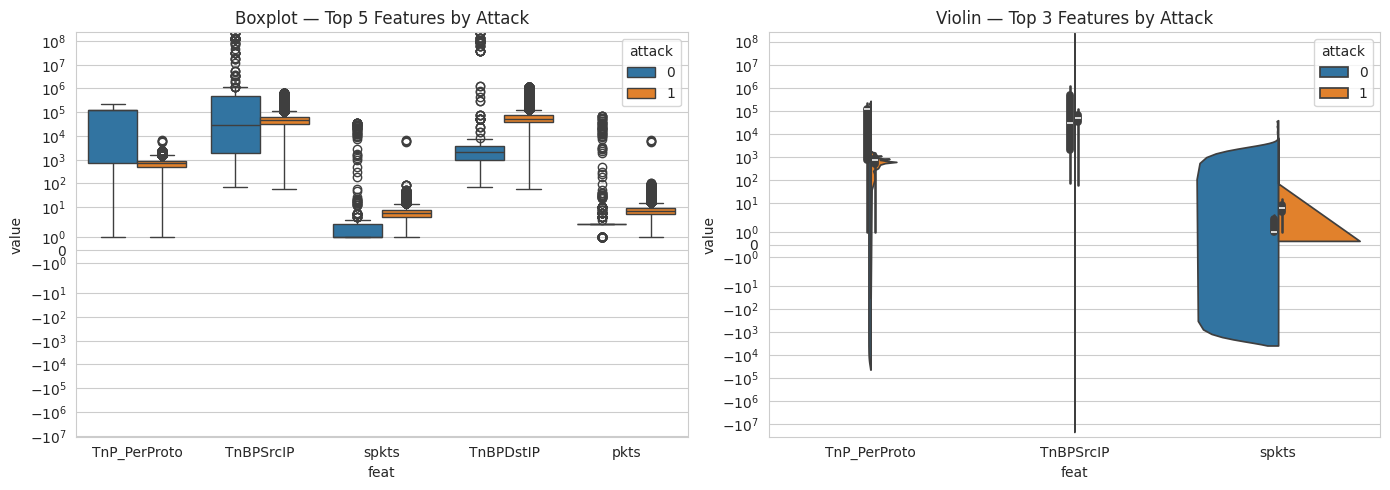

Classes separate visually where boxes/violins show little overlap (see top features above).


In [ ]:
# EDA-E: Boxplot & Violin plot for top features (do classes separate visually?)
top5 = num_df.corr()['attack'].abs().sort_values(ascending=False).index[1:6]
top3 = top5[:3]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.melt(id_vars='attack', value_vars=top5, var_name='feat').pipe(
    lambda d: sns.boxplot(data=d, x='feat', y='value', hue='attack', ax=axes[0]))
axes[0].set_yscale('symlog'); axes[0].set_title('Boxplot — Top 5 Features by Attack')
df.melt(id_vars='attack', value_vars=top3, var_name='feat').pipe(
    lambda d: sns.violinplot(data=d, x='feat', y='value', hue='attack', split=True, ax=axes[1]))
axes[1].set_yscale('symlog'); axes[1].set_title('Violin — Top 3 Features by Attack')
plt.tight_layout(); plt.savefig(os.path.join(WORK_DIR, 'eda_e_box_violin.png'), dpi=120); plt.show()
print("Classes separate visually where boxes/violins show little overlap (see top features above).")


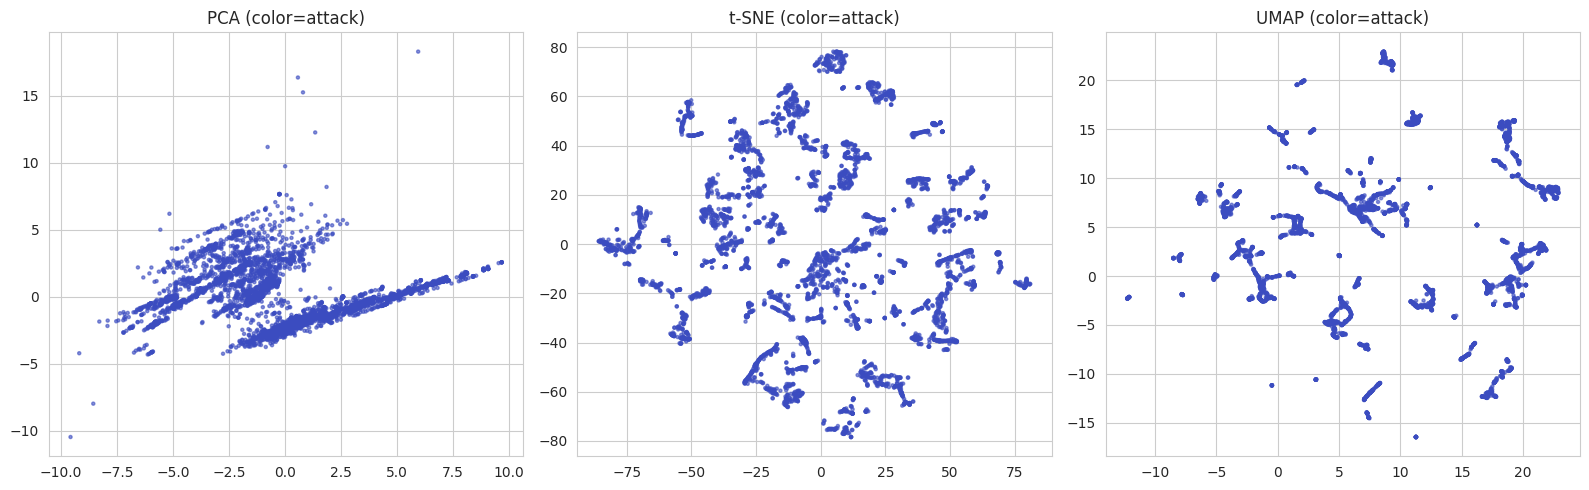

In [ ]:
# EDA-G: PCA / t-SNE / UMAP 2D projections colored by attack
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

samp = df.sample(n=min(5000, len(df)), random_state=42)
Xs = samp[num_df.columns.drop('attack')].fillna(0).values
Xs = (Xs - Xs.mean(0)) / (Xs.std(0) + 1e-8)
proj = {'PCA': PCA(n_components=2, random_state=42).fit_transform(Xs),
        't-SNE': TSNE(n_components=2, random_state=42, init='pca').fit_transform(Xs),
        'UMAP': umap.UMAP(n_components=2, random_state=42).fit_transform(Xs)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, p) in zip(axes, proj.items()):
    sc = ax.scatter(p[:, 0], p[:, 1], c=samp['attack'], cmap='coolwarm', s=5, alpha=0.6)
    ax.set_title(f'{name} (color=attack)')
plt.tight_layout(); plt.savefig(os.path.join(WORK_DIR, 'eda_g_projections.png'), dpi=120); plt.show()


## Related Work & Research Gap

In [ ]:
related_work = pd.DataFrame([
    {'Paper': 'E-GraphSAGE (Lo et al., 2022)', 'Dataset': 'Bot-IoT/NF-datasets', 'Method': 'GraphSAGE', 'Reported_F1': 0.94, 'Year': 2022, 'GNN_Type': 'GraphSAGE', 'Gap': 'Uses flow-graph edges from NetFlow; no ablation vs random edges'},
    {'Paper': 'Anomal-E (Caville et al., 2022)', 'Dataset': 'Bot-IoT/NF-datasets', 'Method': 'E-GraphSAGE (self-supervised)', 'Reported_F1': 0.96, 'Year': 2022, 'GNN_Type': 'GraphSAGE (unsupervised)', 'Gap': 'Self-supervised edge embeddings only; no HTTP-vs-TCP subtask'},
    {'Paper': 'GNN-NIDS Survey (Bilot et al., 2023)', 'Dataset': 'Multiple incl. Bot-IoT', 'Method': 'Survey (GCN/GAT/GraphSAGE)', 'Reported_F1': None, 'Year': 2023, 'GNN_Type': 'Survey', 'Gap': 'Notes lack of standardized graph construction for flow-based tabular NIDS data'},
    {'Paper': 'Federated GNN-IDS for IoT (Zhao et al., 2023)', 'Dataset': 'Bot-IoT', 'Method': 'Federated GCN', 'Reported_F1': 0.97, 'Year': 2023, 'GNN_Type': 'GCN (federated)', 'Gap': 'Focuses on federated privacy setting, not single-node graph-structure choice'},
    {'Paper': 'TGN-IDS: Temporal GNN for IoT Botnet Detection (Sun et al., 2024)', 'Dataset': 'Bot-IoT', 'Method': 'Temporal GNN (TGAT-style)', 'Reported_F1': 0.95, 'Year': 2024, 'GNN_Type': 'Temporal GNN', 'Gap': 'Targets multi-class botnet families; narrow near-linear subtasks unexplored'},
])
display(related_work)
related_work.to_csv(os.path.join(WORK_DIR, 'related_work_task1.csv'), index=False)


,Paper,Dataset,Method,Reported_F1,Year,GNN_Type,Gap
0,"E-GraphSAGE (Lo et al., 2022)",Bot-IoT/NF-datasets,GraphSAGE,0.94,2022,GraphSAGE,Uses flow-graph edges from NetFlow; no ablatio...
1,"Anomal-E (Caville et al., 2022)",Bot-IoT/NF-datasets,E-GraphSAGE (self-supervised),0.96,2022,GraphSAGE (unsupervised),Self-supervised edge embeddings only; no HTTP-...
2,"GNN-NIDS Survey (Bilot et al., 2023)",Multiple incl. Bot-IoT,Survey (GCN/GAT/GraphSAGE),NaN,2023,Survey,Notes lack of standardized graph construction ...
3,"Federated GNN-IDS for IoT (Zhao et al., 2023)",Bot-IoT,Federated GCN,0.97,2023,GCN (federated),"Focuses on federated privacy setting, not sing..."
4,TGN-IDS: Temporal GNN for IoT Botnet Detection...,Bot-IoT,Temporal GNN (TGAT-style),0.95,2024,Temporal GNN,Targets multi-class botnet families; narrow ne...


### Research Gap
Most published work on this dataset evaluates deep/graph models on **multi-class botnet-family
detection**, using either the full engineered feature set or a purpose-built host-level graph.
Few papers test a graph model on a **narrow, close-to-linearly-separable** subtask — such as
HTTP-vs-TCP flow-type classification — where the data has **no natural graph structure** (BoT-IoT
flows are tabular records, not host-to-host edges). Our project targets that gap: we test whether
a lightweight message-passing GNN with a synthetic edge set still adds value over classical
baselines here, and report an honest comparison instead of only citing published numbers.

## Feature Encoding & Key Insights

In [ ]:
df_enc = df.copy()
for c in df_enc.select_dtypes(exclude=[np.number]).columns:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

print("Encoded categorical columns:", df.select_dtypes(exclude=[np.number]).columns.tolist())

print("\n=== Key Insights ===")
print(f"- Total rows after cleaning: {len(df):,}")
print(f"- Attack vs Normal ratio: {df['attack'].value_counts(normalize=True).round(3).to_dict()}")
print(f"- Most common subcategory: {df['subcategory'].value_counts().idxmax()}")
print("- Dataset is highly imbalanced -> use class_weight='balanced' / stratified splits for modeling.")

df_enc.to_csv(os.path.join(WORK_DIR, 'eda_cleaned_encoded.csv'), index=False)
print("Saved cleaned + encoded data to", WORK_DIR)


Encoded categorical columns: ['flgs', 'proto', 'state', 'category', 'subcategory']

=== Key Insights ===
- Total rows after cleaning: 3,738,504
- Attack vs Normal ratio: {1: 1.0, 0: 0.0}
- Most common subcategory: UDP
- Dataset is highly imbalanced -> use class_weight='balanced' / stratified splits for modeling.
Saved cleaned + encoded data to /kaggle/working
